#### Using moving average to answer: What is the forecasted incidence of OHCA till year 2040, based on Pan-Asian Resuscitation Outcomes Study (PAROS) data?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
# read from the collated incident count csv
OHCA_incident_count = pd.read_csv("../../datasets/OHCA_incidents_count.csv")
OHCA_incident_count.head(15)

,Year,Incident Count (Year),Quarter,Incident Count (Quarter),Month,Incident Count (Month)
0,2010.0,1081.0,2010Q2,348.0,2010-04,102
1,2011.0,1377.0,2010Q3,335.0,2010-05,126
2,2012.0,1440.0,2010Q4,398.0,2010-06,120
3,2013.0,1736.0,2011Q1,411.0,2010-07,95
4,2014.0,2038.0,2011Q2,356.0,2010-08,135
5,2015.0,2372.0,2011Q3,331.0,2010-09,105
6,2016.0,2505.0,2011Q4,279.0,2010-10,154
7,2017.0,2841.0,2012Q1,334.0,2010-11,133
8,2018.0,2975.0,2012Q2,354.0,2010-12,111
9,2019.0,3233.0,2012Q3,390.0,2011-01,144


In [12]:
count_by_month = OHCA_incident_count[["Month", "Incident Count (Month)"]]
# .loc ensures I am modifying the original dataframe
count_by_month.loc[:, "Month"] = pd.to_datetime(count_by_month["Month"], format = "%Y-%m").dt.strftime('%Y-%m-%d')
count_by_month = count_by_month.set_index("Month")
count_by_month.head()

,Incident Count (Month)
Month,
2010-04-01,102
2010-05-01,126
2010-06-01,120
2010-07-01,95
2010-08-01,135


#### Using moving average to do a naive forecasting
I want to see how the monthly counts of OHCA reacts to moving average 

##### Simple Moving Average

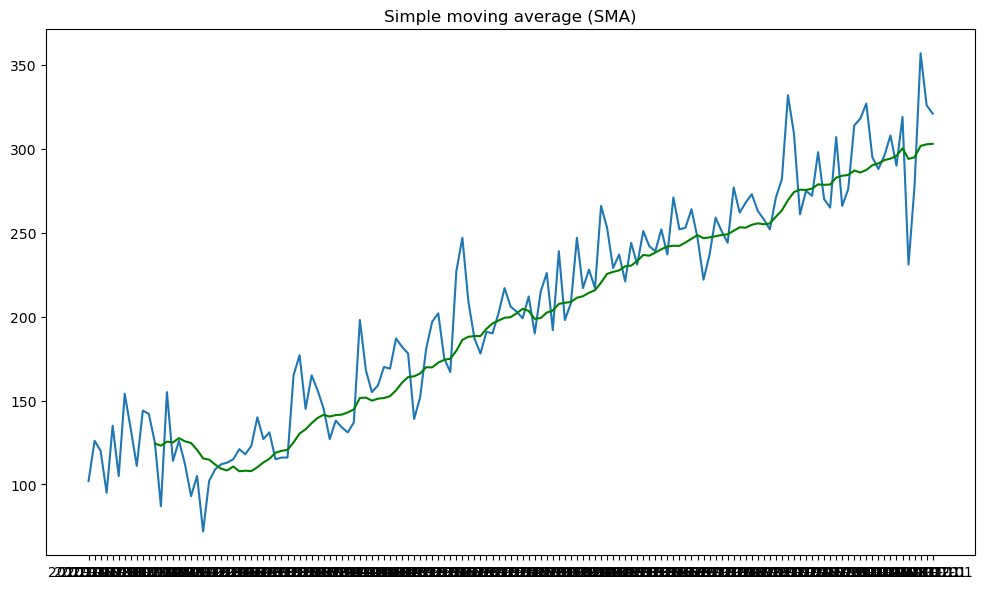

In [22]:
simple_moving_avg = count_by_month.rolling(window = 12).mean()

plt.figure(figsize = (10, 6))
plt.plot(count_by_month, label = "Original")
plt.plot(simple_moving_avg, label = "SMA", color = "green")
plt.title("Simple moving average (SMA)")
plt.tight_layout()
plt.show()

##### Weighted Moving Average

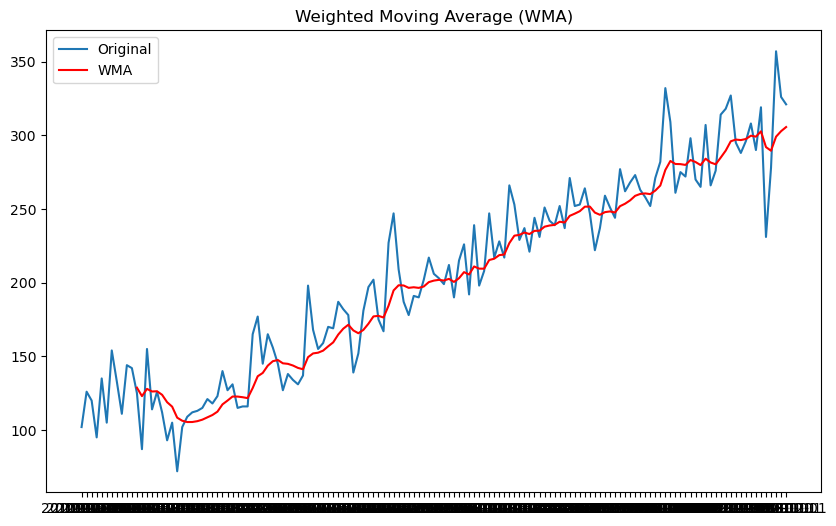

In [25]:
weights = np.arange(1, 13)

weight_moving_average = count_by_month.rolling(window = 12).apply(lambda prices: np.dot(prices, weights)
                                                                                / weights.sum(), raw = True)

plt.figure(figsize = (10, 6))
plt.plot(count_by_month, label = 'Original')
plt.plot(weight_moving_average, label = 'WMA', color = 'red')
plt.title('Weighted Moving Average (WMA)')
plt.legend()
plt.show()

##### Exponential Moving Average

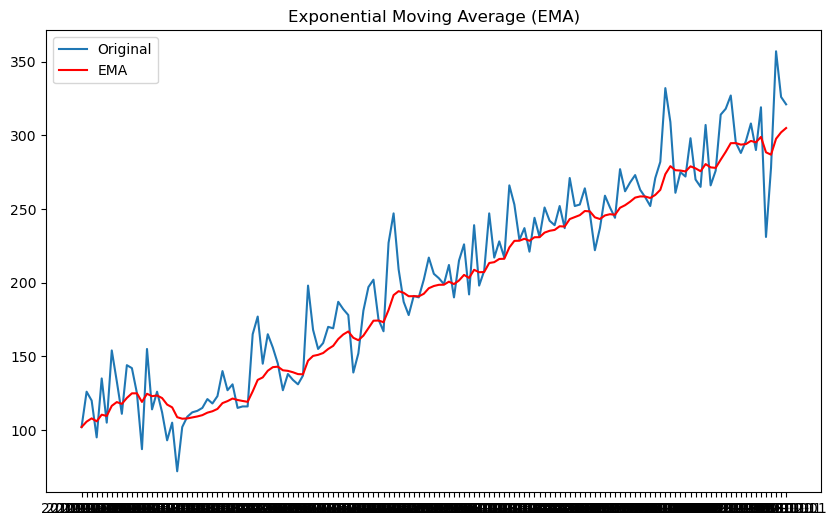

In [26]:
exponential_moving_avg = count_by_month.ewm(span = 12, adjust = False).mean()

plt.figure(figsize = (10, 6))
plt.plot(count_by_month, label = 'Original')
plt.plot(exponential_moving_avg, label = 'EMA', color = 'red')
plt.title('Exponential Moving Average (EMA)')
plt.legend()
plt.show()

##### Spliting the dataset

In [30]:
training_df = count_by_month[(count_by_month.index >= '2010-4') &
                             (count_by_month.index <= '2019-12')]
print(training_df.head())
testing_df = count_by_month[(count_by_month.index >= '2020-1') &
                            (count_by_month.index <= '2021-12')]
print(testing_df.head())


            Incident Count (Month)
Month                             
2011-01-01                     144
2011-02-01                     142
2011-03-01                     125
2011-04-01                      87
2011-05-01                     155
            Incident Count (Month)
Month                             
2020-10-01                     276
2020-11-01                     314
2020-12-01                     318
2021-01-01                     327
2021-02-01                     295


##### Using decaying weights moving average to forecast
This gives more recent trends higher weights than older ones

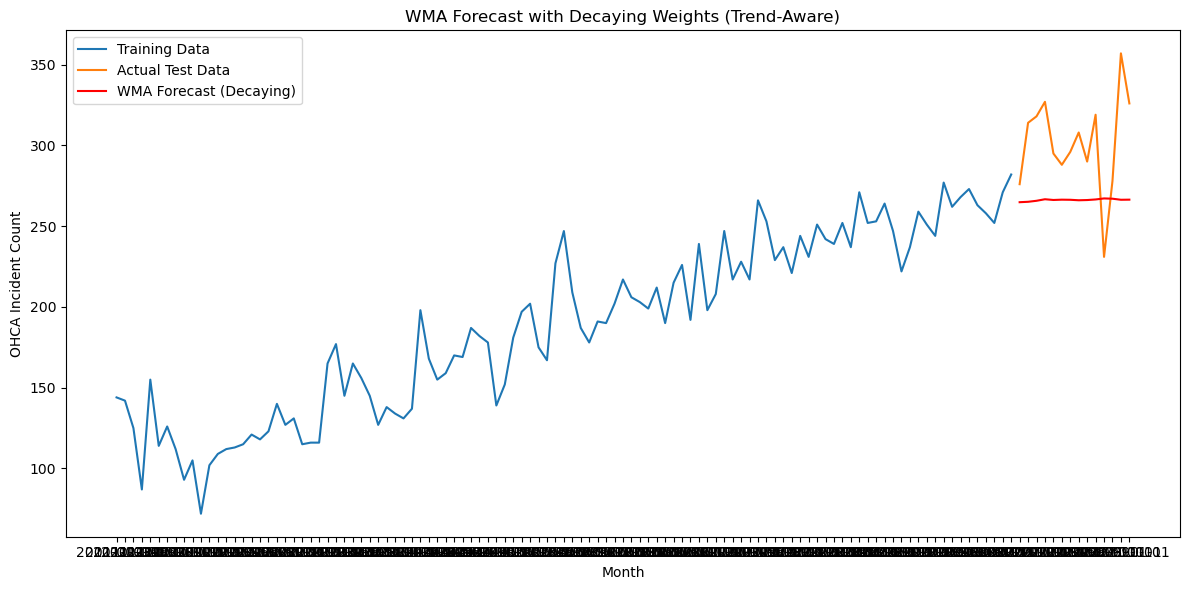

In [45]:
# define weights
window = 12
weights = np.exp(np.linspace(-1., 0., window))  # exponential decay (oldest to newest)
weights /= weights.sum()  # normalize to sum to 1

# prepare training data
train_series = training_df["Incident Count (Month)"].copy()
# last 12 months of training data
history = list(train_series[-window:])
# print(history)

# forecast for each month in 2020 - 2021
forecast_values = []
forecast_index = testing_df.index
# print(forecast_index)

for _ in range(len(forecast_index)):
    # compute forecast using last 12 (can include past forecasts)
    window_vals = history[-window:]
    next_val = np.dot(window_vals, weights)
    forecast_values.append(next_val)
    history.append(next_val)  # extend with forecast for next step

forecast_df = pd.DataFrame({
    "Month": forecast_index,
    "Forecast": forecast_values
}).set_index("Month")


plt.figure(figsize=(12, 6))
plt.plot(train_series, label='Training Data')
plt.plot(testing_df['Incident Count (Month)'], label='Actual Test Data')
plt.plot(forecast_df['Forecast'], label='WMA Forecast (Decaying)', color='red')
plt.title('WMA Forecast with Decaying Weights (Trend-Aware)')
plt.xlabel('Month')
plt.ylabel('OHCA Incident Count')
plt.legend()
plt.tight_layout()
plt.show()

##### Evaluating forecast accuracy

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(testing_df['Incident Count (Month)'], forecast_df['Forecast'])
rmse = np.sqrt(mean_squared_error(testing_df['Incident Count (Month)'], forecast_df['Forecast']))

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')


MAE: 40.59
RMSE: 45.77


##### weighted moving average doesnt seem to be working...